In [225]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.signal import find_peaks
import seaborn as sns
from scipy import stats
import pyvinecopulib as pv
from scipy.interpolate import interp1d

from py_banshee.copula_test import cvm_statistic
from py_banshee.rankcorr import bn_rankcorr
from py_banshee.bn_plot import bn_visualize
from py_banshee.d_cal import test_distance
from py_banshee.copula_test import cvm_statistic
from py_banshee.prediction import inference,conditional_margins_hist

import importlib
import functions as fn
importlib.reload(functions)
%autoreload 2

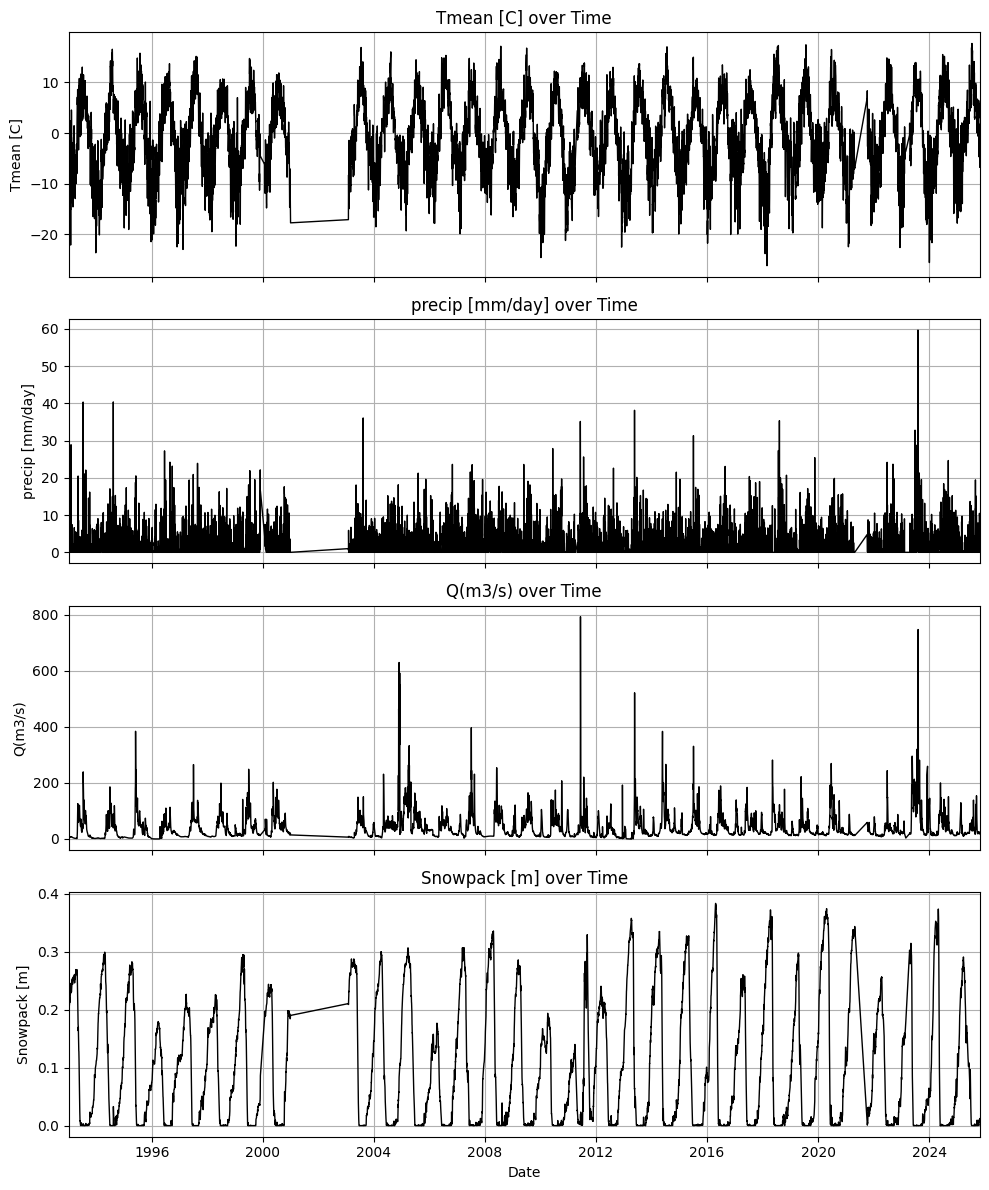

In [226]:
df = fn.import_data("..\\Data\\processed_data.csv")
fn.plot_all(df)


In [227]:
# fn.plot_discharge(df)

In [228]:
# fn.plot_temperature(df)

In [229]:
# fn.plot_precipitation(df)

In [230]:
# fn.plot_snowdepth(df)

Precip and Snowpack both have many repeated values, which are probably zero, they are assigned the same rank.
after scaling to [0,1], this produces many points with the same u-value, which appear as horizontal or verical lines. 
The vertical stripes indicate many tied observations in the original variables, (zero precipitation)
Dependence the copula is meant to model. 

In [231]:
print(df.columns)

Index(['Tmean [C]', 'precip [mm/day]', 'Q(m3/s)', 'Snowpack [m]'], dtype='object')


In [232]:
#import warnings  
#warnings.filterwarnings("ignore")

#M = cvm_statistic(DATA = df, names = data.columns, fig_name='cvm')#your code here. Use Banshee!
#print(M)

In [233]:
#import warnings  
#warnings.filterwarnings("ignore")

#M = cvm_statistic(DATA = df, plot = 1, names = df.columns, fig_name='cvm')
#plt.show()

In [234]:
data = df[["Q(m3/s)"]].copy()
data.dropna(inplace=True)
peaks, _ = find_peaks(data["Q(m3/s)"].values, height=200, distance=32)
exces = data.iloc[peaks]["Q(m3/s)"].values
dpeak = data.index[peaks]

df_max_Q = pd.DataFrame()

df_max_Q['exces'] = exces
df_max_Q['date'] = dpeak


In [235]:
print(df.columns)

Index(['Tmean [C]', 'precip [mm/day]', 'Q(m3/s)', 'Snowpack [m]'], dtype='object')


In [236]:
df['Year'] = df.index.year
df['Month'] = df.index.month

idx_max = (
    df.groupby(['Year'])['Q(m3/s)']
      .idxmax()
      .dropna()
)

max_list = df.loc[idx_max]
display(max_list)

,Tmean [C],precip [mm/day],Q(m3/s),Snowpack [m],Year,Month
date,,,,,,
1993-07-13,6.416667,6.705699,239.157100,0.003152,1993,7
1994-06-30,4.653334,0.000000,185.712500,0.001034,1994,6
1995-06-02,5.503334,0.000000,383.985200,0.091657,1995,6
1996-08-28,7.763333,0.000000,113.080000,0.000000,1996,8
1997-07-03,11.020000,0.000000,265.306300,0.000000,1997,7
1998-06-29,6.503333,4.156644,199.251500,0.000000,1998,6
1999-06-29,7.466666,2.584340,248.661300,0.000000,1999,6
2000-05-18,3.223333,1.909716,202.076233,0.050608,2000,5
2003-08-16,7.893333,1.510912,150.487863,0.000444,2003,8


In [237]:
data_snow = pd.DataFrame()
data_snow = df[["Snowpack [m]", "Year", "Month"]].copy()

data_snow = data_snow[data_snow["Snowpack [m]"] > 0]
data_snow = data_snow.dropna()

# display(data_snow)

## calculate snowpack over month ~sum
monthly_sum_snow = data_snow.groupby(['Year', 'Month'])['Snowpack [m]'].sum()
# print(monthly_sum_snow)

# print(monthly_sum_snow.loc[(1992, 11):(1992, 12)])

winter_snowpack1990 = monthly_sum_snow.loc[1990][0:3]
print(winter_snowpack1990)

Month
1    4.430062
2    5.936291
3    6.745495
Name: Snowpack [m], dtype: float64


In [238]:
winter_snowpack = {}
for year in range(1993, 2026):
    winter_snowpack[year] = np.sum(monthly_sum_snow.loc[year][0:3]) + np.sum(monthly_sum_snow.loc[year-1][10:11])
    #print(f"Winter snowpack for year {year}:")
    #print(winter_snowpack[year])
for y in [2001, 2002]:
    winter_snowpack.pop(y, None)

The spearman correlation coefficient for winter snowpack (Nov) is: 0.2556451612903226
The correlation coefficient for winter snowpack (Nov) is: 0.21043733706208131
The spearman correlation coefficient for winter snowpack (Dec) is: -0.010898088293170863
The correlation coefficient for winter snowpack (Dec) is: -0.24353223167909477
The spearman correlation coefficient for winter snowpack (Jan) is: 0.4161290322580646
The correlation coefficient for winter snowpack (Jan) is: 0.11334543947464729
The spearman correlation coefficient for winter snowpack (Feb) is: 0.31935483870967746
The correlation coefficient for winter snowpack (Feb) is: -0.02383354998509518
The strongest pearson correlation is for month: Nov with value: 0.21043733706208131
The strongest spearman correlation is for month: Jan with value: 0.4161290322580646


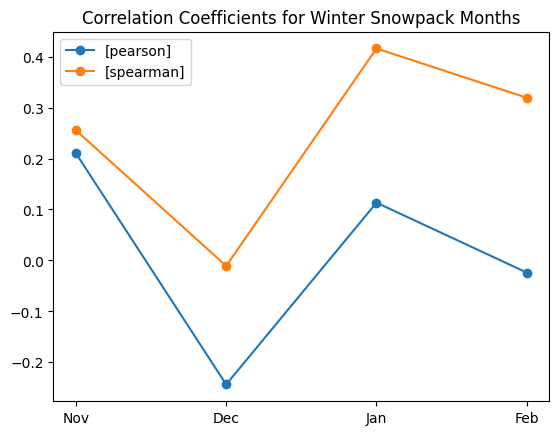

In [239]:
#calculate strongest correlation for each month in winter for each extreme event 
months_info = {
    'Nov': (-1, 10, 11),  # year offset, start month idx, end month idx (exclusive)
    'Dec': (-1, 11, 12),
    'Jan': (0, 0, 1),
    'Feb': (0, 1, 2)
}

rhos = []
spearman = []

for m, (y_off, start_idx, end_idx) in months_info.items():
    snowpack = {}

    for year in range(1993, 2026):
        if year in [2001, 2002]:
            continue

        values = monthly_sum_snow.loc[year + y_off][start_idx:end_idx]

        snowpack[year] = np.sum(values)  

    rho = stats.pearsonr(max_list['Q(m3/s)'], list(snowpack.values()))[0]
    rhos.append(rho)
    spearman_rho = stats.spearmanr(max_list['Q(m3/s)'], list(snowpack.values()))[0]
    spearman.append(spearman_rho)
    print(f'The spearman correlation coefficient for winter snowpack ({m}) is:', spearman_rho)

    print(f'The correlation coefficient for winter snowpack ({m}) is:', rho)

plt.plot(list(months_info.keys()), rhos, marker='o', label = '[pearson]')
plt.plot(list(months_info.keys()), spearman, marker='o', label = '[spearman]')
plt.title('Correlation Coefficients for Winter Snowpack Months')
plt.legend()

print('The strongest pearson correlation is for month:', list(months_info.keys())[np.argmax(rhos)], 'with value:', np.max(rhos))
print('The strongest spearman correlation is for month:', list(months_info.keys())[np.argmax(spearman)], 'with value:', np.max(spearman))

The strongest correlation is for 3 months cummulative snowpack with spearman rho = 0.32620967741935486


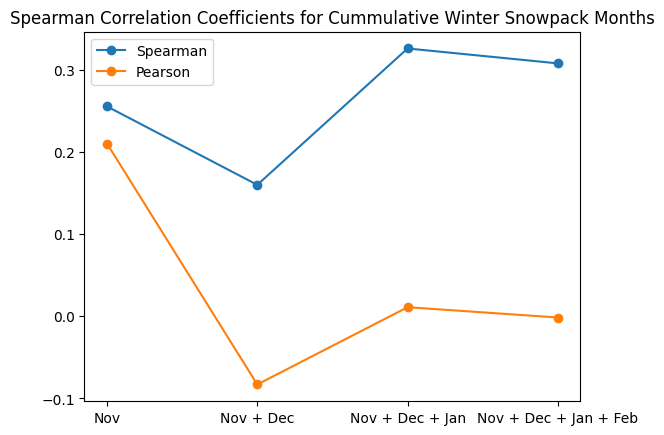

In [240]:
#calculate each cummulative month correlation
winter_snowpack_1month = {}
for year in range(1993, 2026):
    winter_snowpack_1month[year] = np.sum(monthly_sum_snow.loc[year-1][10:11])
for y in [2001, 2002]:
    winter_snowpack_1month.pop(y, None)

rho_snow_1month = stats.pearsonr(max_list['Q(m3/s)'], list(winter_snowpack_1month.values()))
spearman_rho_1month = stats.spearmanr(max_list['Q(m3/s)'], list(winter_snowpack_1month.values()))


winter_snowpack_2month = {}
for year in range(1993, 2026):
    winter_snowpack_2month[year] =np.sum(monthly_sum_snow.loc[year-1][10:12])
for y in [2001, 2002]:
    winter_snowpack_2month.pop(y, None)
rho_snow_2month = stats.pearsonr(max_list['Q(m3/s)'], list(winter_snowpack_2month.values()))
spearman_rho_2month = stats.spearmanr(max_list['Q(m3/s)'], list(winter_snowpack_2month.values()))


winter_snowpack_3month = {}
for year in range(1993, 2026):
    winter_snowpack_3month[year] = np.sum(monthly_sum_snow.loc[year-1][10:12]) + np.sum(monthly_sum_snow.loc[year][0:1])
for y in [2001, 2002]:
    winter_snowpack_3month.pop(y, None)
rho_snow_3month = stats.pearsonr(max_list['Q(m3/s)'], list(winter_snowpack_3month.values()))
spearman_rho_3month = stats.spearmanr(max_list['Q(m3/s)'], list(winter_snowpack_3month.values()))


winter_snowpack_4month = {}
for year in range(1993, 2026):
    winter_snowpack_4month[year] = np.sum(monthly_sum_snow.loc[year][0:2])  +  np.sum(monthly_sum_snow.loc[year-1][10:12])
for y in [2001, 2002]:
    winter_snowpack_4month.pop(y, None)
rho_snow_4month = stats.pearsonr(max_list['Q(m3/s)'], list(winter_snowpack_4month.values()))
spearman_rho_4month = stats.spearmanr(max_list['Q(m3/s)'], list(winter_snowpack_4month.values()))

months = ['Nov', 'Nov + Dec', 'Nov + Dec + Jan', 'Nov + Dec + Jan + Feb']
spearman_months = [spearman_rho_1month[0], spearman_rho_2month[0], spearman_rho_3month[0], spearman_rho_4month[0]]
pearson_months = [rho_snow_1month[0], rho_snow_2month[0], rho_snow_3month[0], rho_snow_4month[0]]

plt.plot(months, spearman_months, marker='o', label='Spearman')
plt.plot(months, pearson_months, marker='o', label='Pearson')
plt.title('Spearman Correlation Coefficients for Cummulative Winter Snowpack Months')
plt.legend()

print('The strongest correlation is for 3 months cummulative snowpack with spearman rho =', spearman_rho_3month[0])

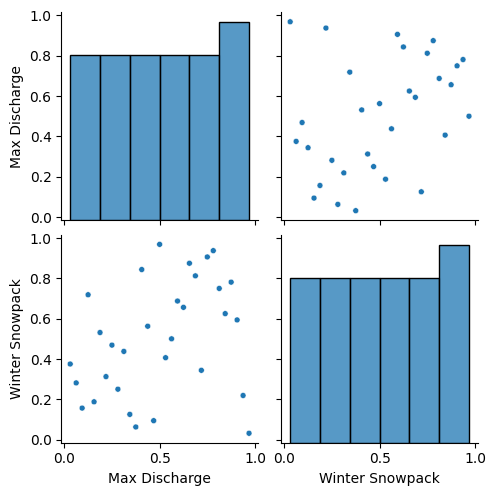

In [241]:
def unity(data):
    u_hat = data.copy()
    n = len(data)
    for col in data.columns:
        u_hat[col]= stats.rankdata(data[col]) / (n + 1)
    return u_hat

def sd_normal(data):
    sd_normal_df = data.copy()
    for col in data.columns:
        sd_normal_df[col] = stats.norm.ppf(data[col])
    return sd_normal_df


unity_df = unity(pd.DataFrame({'Max Discharge': max_list['Q(m3/s)'].values, 'Winter Snowpack': list(winter_snowpack_3month.values())}))
sns.pairplot(data=unity_df, height=2.5, plot_kws = dict(size=0.1))

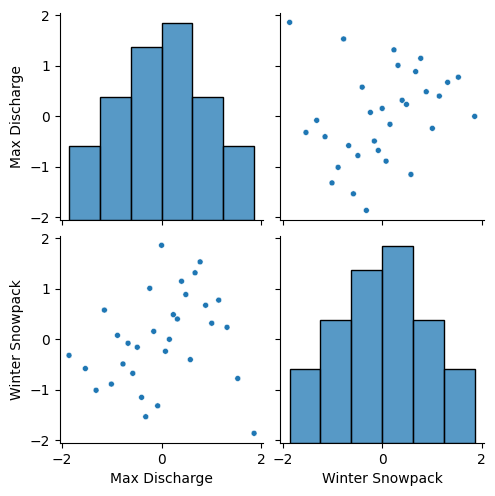

In [242]:
sd_data = sd_normal(unity_df)
sns.pairplot(sd_data, height=2.5,plot_kws=dict(size=.1))
plt.show()

In [243]:
precip1993 = np.sum(df['precip [mm/day]'].loc['1993-07-06':'1993-07-13'])
print(precip1993)

precip1994 = np.sum(df['precip [mm/day]'].loc['1994-06-24':'1994-06-30'])
print(precip1994)

precip1995 = np.sum(df['precip [mm/day]'].loc['1995-05-25':'1995-06-02'])
print(precip1995)

precip1996 = np.sum(df['precip [mm/day]'].loc['1996-08-21':'1996-08-28'])
print(precip1996)

precip1997 = np.sum(df['precip [mm/day]'].loc['1997-06-26':'1997-07-03'])
print(precip1997)

precip1998 = np.sum(df['precip [mm/day]'].loc['1998-06-22':'1998-06-29'])



70.025462
29.106485999999997
58.782087000000004
58.2748063
54.2982945


In [244]:
#calculate precip over 5 days prior to peak discharge
precip = np.zeros(len(max_list))

for i, date in enumerate(max_list.index):

    precip[i] = df.loc[date - pd.Timedelta(days=5):date, 'precip [mm/day]'].sum()

        
print(precip)


[ 68.092821    26.890005    53.186526    53.0470583   52.0867635
  23.824232    32.07016      8.17342     75.83504     27.0240754
  12.074175     0.          32.58953      0.          47.398585
  65.494845   100.881457     5.29838204  57.191805    16.141804
  42.813773    32.718293    40.686198    18.796685    34.505292
  19.65936798   3.062708    45.766521   127.83029     30.0393742
  39.058058  ]


The correlation coefficient for 1-day precipitation is: 0.46480910056474184
The spearman correlation coefficient for 1-day precipitation is: 0.12948770718714187
The correlation coefficient for 2-day precipitation is: 0.6334502593624386
The spearman correlation coefficient for 2-day precipitation is: 0.2544611364882503
The correlation coefficient for 3-day precipitation is: 0.6051832525394204
The spearman correlation coefficient for 3-day precipitation is: 0.23591087931161087
The correlation coefficient for 4-day precipitation is: 0.5687436144528442
The spearman correlation coefficient for 4-day precipitation is: 0.19639076619616153
The correlation coefficient for 5-day precipitation is: 0.5521407797446556
The spearman correlation coefficient for 5-day precipitation is: 0.20445609540339607
The correlation coefficient for 6-day precipitation is: 0.5499225370938644
The spearman correlation coefficient for 6-day precipitation is: 0.22703901718365282
The correlation coefficient for 7-day pr

Text(0, 0.5, 'Correlation coefficient')

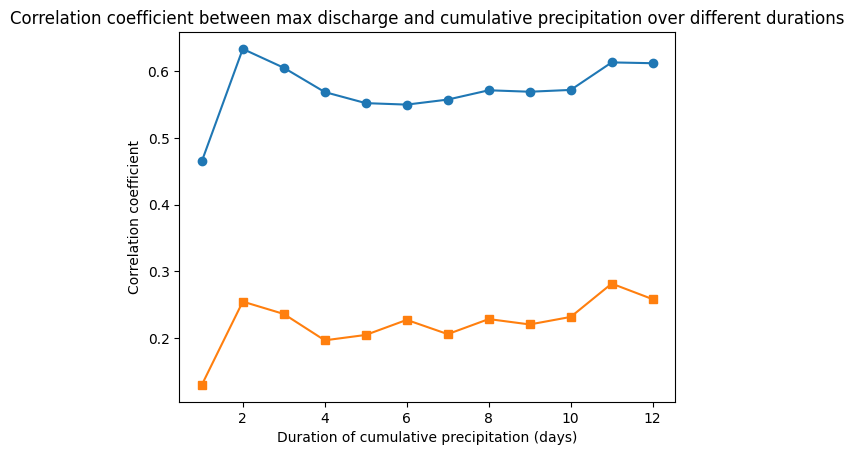

In [245]:
#find strongest relation for cummulative precip over 1 to 10 days prior to peak discharge
precip1d = np.zeros(len(max_list))

for i, date in enumerate(max_list.index):
    precip1d[i] = df.loc[date - pd.Timedelta(days=1):date, 'precip [mm/day]'].sum()

rho_1 = stats.pearsonr(max_list['Q(m3/s)'], precip1d)
print('The correlation coefficient for 1-day precipitation is:', rho_1[0])
spearman_1 = stats.spearmanr(max_list['Q(m3/s)'], precip1d)
print('The spearman correlation coefficient for 1-day precipitation is:', spearman_1[0])

precip2d = np.zeros(len(max_list))
for i, date in enumerate(max_list.index):
    precip2d[i] = df.loc[date - pd.Timedelta(days=2):date, 'precip [mm/day]'].sum()
rho_2 = stats.pearsonr(max_list['Q(m3/s)'], precip2d)
print('The correlation coefficient for 2-day precipitation is:', rho_2[0])
spearman_2 = stats.spearmanr(max_list['Q(m3/s)'], precip2d)
print('The spearman correlation coefficient for 2-day precipitation is:', spearman_2[0])

precip3d = np.zeros(len(max_list))
for i, date in enumerate(max_list.index):
    precip3d[i] = df.loc[date - pd.Timedelta(days=3):date, 'precip [mm/day]'].sum() 
rho_3 = stats.pearsonr(max_list['Q(m3/s)'], precip3d)
print('The correlation coefficient for 3-day precipitation is:', rho_3[0])
spearman_3 = stats.spearmanr(max_list['Q(m3/s)'], precip3d)
print('The spearman correlation coefficient for 3-day precipitation is:', spearman_3[0])

precip4d = np.zeros(len(max_list))
for i, date in enumerate(max_list.index):
    precip4d[i] = df.loc[date - pd.Timedelta(days=4):date, 'precip [mm/day]'].sum() 
rho_4 = stats.pearsonr(max_list['Q(m3/s)'], precip4d)
print('The correlation coefficient for 4-day precipitation is:', rho_4[0])
spearman_4 = stats.spearmanr(max_list['Q(m3/s)'], precip4d)
print('The spearman correlation coefficient for 4-day precipitation is:', spearman_4[0])

precip5d = np.zeros(len(max_list))
for i, date in enumerate(max_list.index):
    precip5d[i] = df.loc[date - pd.Timedelta(days=5):date, 'precip [mm/day]'].sum() 
rho_5 = stats.pearsonr(max_list['Q(m3/s)'], precip5d)
print('The correlation coefficient for 5-day precipitation is:', rho_5[0])
spearman_5 = stats.spearmanr(max_list['Q(m3/s)'], precip5d)
print('The spearman correlation coefficient for 5-day precipitation is:', spearman_5[0])

precip6d = np.zeros(len(max_list))
for i, date in enumerate(max_list.index):
    precip6d[i] = df.loc[date - pd.Timedelta(days=6):date, 'precip [mm/day]'].sum() 
rho_6 = stats.pearsonr(max_list['Q(m3/s)'], precip6d)
print('The correlation coefficient for 6-day precipitation is:', rho_6[0])
spearman_6 = stats.spearmanr(max_list['Q(m3/s)'], precip6d)
print('The spearman correlation coefficient for 6-day precipitation is:', spearman_6[0])

precip7d = np.zeros(len(max_list))
for i, date in enumerate(max_list.index):
    precip7d[i] = df.loc[date - pd.Timedelta(days=7):date, 'precip [mm/day]'].sum() 
rho_7 = stats.pearsonr(max_list['Q(m3/s)'], precip7d)
print('The correlation coefficient for 7-day precipitation is:', rho_7[0])
spearman_7 = stats.spearmanr(max_list['Q(m3/s)'], precip7d)
print('The spearman correlation coefficient for 7-day precipitation is:', spearman_7[0])

precip8d = np.zeros(len(max_list))
for i, date in enumerate(max_list.index):
    precip8d[i] = df.loc[date - pd.Timedelta(days=8):date, 'precip [mm/day]'].sum()

rho_8 = stats.pearsonr(max_list['Q(m3/s)'], precip8d)
print('The correlation coefficient for 8-day precipitation is:', rho_8[0])
spearman_8 = stats.spearmanr(max_list['Q(m3/s)'], precip8d)
print('The spearman correlation coefficient for 8-day precipitation is:', spearman_8[0])

precip9d = np.zeros(len(max_list))
for i, date in enumerate(max_list.index):
    precip9d[i] = df.loc[date - pd.Timedelta(days=9):date, 'precip [mm/day]'].sum()
rho_9 = stats.pearsonr(max_list['Q(m3/s)'], precip9d)
print('The correlation coefficient for 9-day precipitation is:', rho_9[0])
spearman_9 = stats.spearmanr(max_list['Q(m3/s)'], precip9d)
print('The spearman correlation coefficient for 9-day precipitation is:', spearman_9[0])

precip10d = np.zeros(len(max_list))
for i, date in enumerate(max_list.index):
    precip10d[i] = df.loc[date - pd.Timedelta(days=10):date, 'precip [mm/day]'].sum()   
rho_10 = stats.pearsonr(max_list['Q(m3/s)'], precip10d)
print('The correlation coefficient for 10-day precipitation is:', rho_10[0])
spearman_10 = stats.spearmanr(max_list['Q(m3/s)'], precip10d)
print('The spearman correlation coefficient for 10-day precipitation is:', spearman_10[0])

precip11d = np.zeros(len(max_list))
for i, date in enumerate(max_list.index):
    precip11d[i] = df.loc[date - pd.Timedelta(days=11):date, 'precip [mm/day]'].sum()
rho_11 = stats.pearsonr(max_list['Q(m3/s)'], precip11d)
print('The correlation coefficient for 11-day precipitation is:', rho_11[0])
spearman_11 = stats.spearmanr(max_list['Q(m3/s)'], precip11d)
print('The spearman correlation coefficient for 11-day precipitation is:', spearman_11[0])

precip12d = np.zeros(len(max_list))
for i, date in enumerate(max_list.index):
    precip12d[i] = df.loc[date - pd.Timedelta(days=12):date, 'precip [mm/day]'].sum()
rho_12 = stats.pearsonr(max_list['Q(m3/s)'], precip12d)
print('The correlation coefficient for 12-day precipitation is:', rho_12[0])
spearman_12 = stats.spearmanr(max_list['Q(m3/s)'], precip12d)
print('The spearman correlation coefficient for 12-day precipitation is:', spearman_12[0])

days = np.array([1,2,3,4,5,6,7,8,9,10,11,12])
rhos = np.array([rho_1[0], rho_2[0], rho_3[0], rho_4[0], rho_5[0], rho_6[0], rho_7[0], rho_8[0], rho_9[0], rho_10[0], rho_11[0], rho_12[0]])
spearmans = np.array([spearman_1[0], spearman_2[0], spearman_3[0], spearman_4[0], spearman_5[0], spearman_6[0], spearman_7[0], spearman_8[0], spearman_9[0], spearman_10[0], spearman_11[0], spearman_12[0]])



plt.plot(days, rhos, marker='o', label='Pearson')
plt.plot(days, spearmans, marker='s', label='Spearman')
plt.title('Correlation coefficient between max discharge and cumulative precipitation over different durations')
plt.xlabel('Duration of cumulative precipitation (days)')
plt.ylabel('Correlation coefficient')

Text(0, 0.5, 'Cumulative Precipitation [mm]')

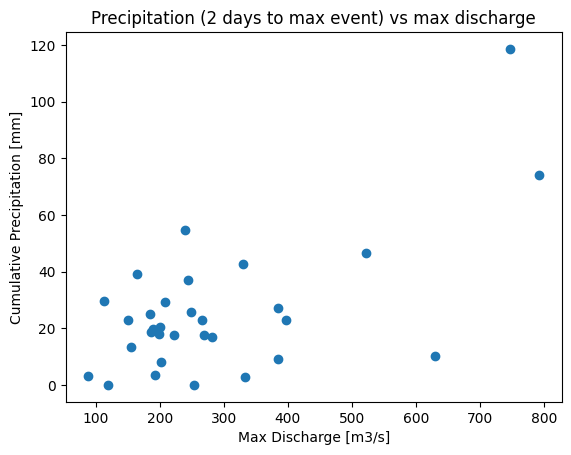

In [246]:
plt.scatter(max_list['Q(m3/s)'], precip2d)
plt.title('Precipitation (2 days to max event) vs max discharge')
plt.xlabel('Max Discharge [m3/s]')
plt.ylabel('Cumulative Precipitation [mm]')



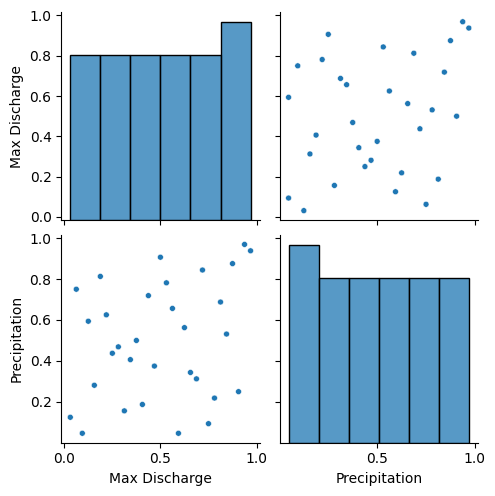

In [247]:
unity_df = unity(pd.DataFrame({'Max Discharge': max_list['Q(m3/s)'].values, 'Precipitation': precip2d}))
sns.pairplot(data=unity_df, height=2.5, plot_kws = dict(size=0.1))

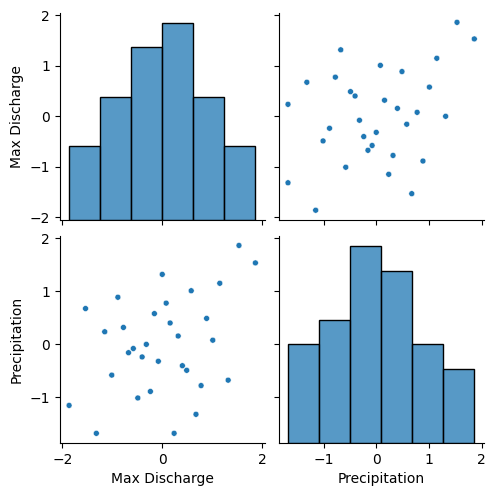

In [248]:
sd_data = sd_normal(unity_df)
sns.pairplot(sd_data, height=2.5,plot_kws=dict(size=.1))
plt.show()


In [249]:
#plan voor temperatuur: tellen van aantal dagen voor extreem event met temp boven bepaalde drempel (0 graden) 

temp_count = np.zeros(len(max_list))

for i, date in enumerate(max_list.index):
    date_0 = pd.Timestamp(year=date.year, month=1, day=1)
    temp_count[i] = np.sum(df['Tmean [C]'].loc[date_0:date] > 0)
print(temp_count)

rho_temp = stats.pearsonr(max_list['Q(m3/s)'], temp_count)
print('The correlation coefficient for number of days with temperature above 0C is:', rho_temp[0])

spearman_temp = stats.spearmanr(max_list['Q(m3/s)'], temp_count)
print('The spearman correlation coefficient for number of days with temperature above 0C is:', spearman_temp[0])

rho_temp_snow = stats.pearsonr(temp_count, list(winter_snowpack_3month.values()))
print('The correlation coefficient between number of days with temperature above 0C and winter snowpack is:', rho_temp_snow[0])
spearman_temp_snow = stats.spearmanr(temp_count, list(winter_snowpack_3month.values()))
print('The spearman correlation coefficient between number of days with temperature above 0C and winter snowpack is:', spearman_temp_snow[0])
print('Strongest correlation is for days above zero mean temp and winter snowpack with spearman rho =', spearman_temp_snow[0], 'and pearson rho =', rho_temp_snow[0])

[ 83.  52.  24. 116.  65.  68.  64.  30. 110. 174.   6.  35.  76.  37.
  95. 148.  57. 141.  20.  31.  51.  53.  48.  19.  33.  48.   0.  67.
  97.  37. 161.]
The correlation coefficient for number of days with temperature above 0C is: 0.054769650869759184
The spearman correlation coefficient for number of days with temperature above 0C is: -0.14781206188816584
The correlation coefficient between number of days with temperature above 0C and winter snowpack is: -0.14862422902644395
The spearman correlation coefficient between number of days with temperature above 0C and winter snowpack is: -0.23593466904386634
Strongest correlation is for days above zero mean temp and winter snowpack with spearman rho = -0.23593466904386634 and pearson rho = -0.14862422902644395


In [250]:
temp_mean = np.zeros(len(max_list))
for i, date in enumerate(max_list.index):
    date_0 = pd.Timestamp(year=date.year, month=1, day=1)
    temp_mean[i] = np.mean(df['Tmean [C]'].loc[date_0:date])
print(temp_mean)

rho_temp = stats.pearsonr(max_list['Q(m3/s)'], temp_mean)
print('The correlation coefficient for mean temperature is:', rho_temp[0])

spearman_temp = stats.spearmanr(max_list['Q(m3/s)'], temp_mean)
print('The spearman correlation coefficient for mean temperature is:', spearman_temp[0])

rho_temp_snow = stats.pearsonr(temp_mean, list(winter_snowpack_3month.values()))
print('The correlation coefficient between mean temperature and winter snowpack is:', rho_temp_snow[0])
spearman_temp_snow = stats.spearmanr(temp_mean, list(winter_snowpack_3month.values()))
print('The spearman correlation coefficient between mean temperature and winter snowpack is:', spearman_temp_snow[0])   


[ -1.86256022  -4.91567205  -5.43657917  -1.10858927  -2.8804529
  -2.90235177  -3.16603707  -4.3097599    0.68865495  -0.06780784
  -6.4152997   -4.7197574   -1.71516928  -3.79850398  -0.92268988
  -0.58688097  -3.23230447  -1.44595993  -7.7099297   -4.25036776
  -2.89847524  -3.95145254  -3.35304518  -7.94676828  -4.61899775
  -2.3977778  -14.92137626  -2.04731489  -0.98713427  -4.4906443
   1.57143395]
The correlation coefficient for mean temperature is: 0.09859036303985629
The spearman correlation coefficient for mean temperature is: -0.0814516129032258
The correlation coefficient between mean temperature and winter snowpack is: -0.1083896486660659
The spearman correlation coefficient between mean temperature and winter snowpack is: -0.09193548387096774


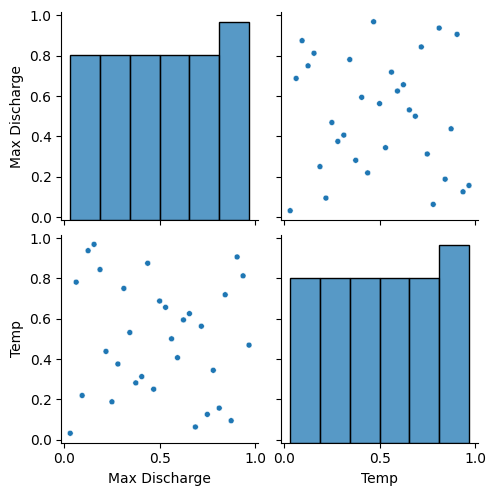

In [251]:
unity_df = unity(pd.DataFrame({'Max Discharge': max_list['Q(m3/s)'].values, 'Temp': temp_mean}))
sns.pairplot(data=unity_df, height=2.5, plot_kws = dict(size=0.1))

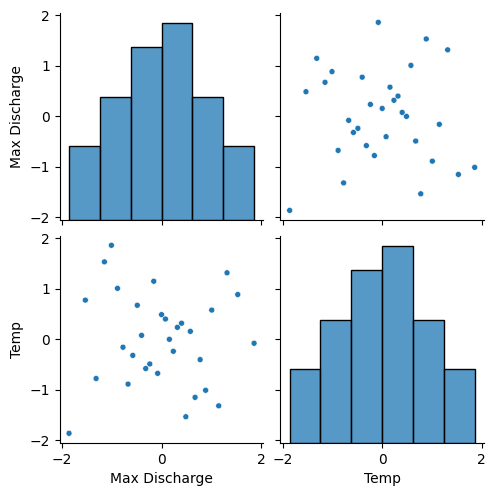

In [252]:
sd_data = sd_normal(unity_df)
sns.pairplot(sd_data, height=2.5,plot_kws=dict(size=.1))
plt.show()

In [253]:
data = pd.DataFrame({'days above zero temp': temp_count, 'Precipitation 2 days': precip2d, 'snowpack winter months': list(winter_snowpack_3month.values()), 'Max Discharge': max_list['Q(m3/s)']})
display(data)

,days above zero temp,Precipitation 2 days,snowpack winter months,Max Discharge
date,,,,
1993-07-13,83.0,54.667362,13.035959,239.157100
1994-06-30,52.0,18.541507,8.108350,185.712500
1995-06-02,24.0,27.164099,10.626453,383.985200
1996-08-28,116.0,29.583591,6.413787,113.080000
1997-07-03,65.0,22.975514,9.724399,265.306300
1998-06-29,68.0,17.915976,4.779759,199.251500
1999-06-29,64.0,25.664130,8.308645,248.661300
2000-05-18,30.0,8.173420,11.143735,202.076233
2003-08-16,110.0,23.063913,10.500377,150.487863


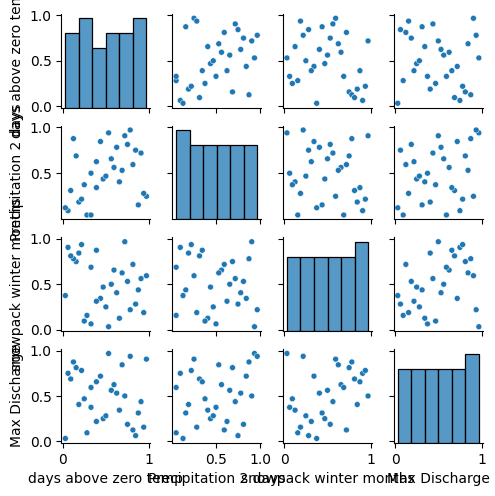

In [254]:
def unity(data):
    u_hat = data.copy()
    for col in data.columns:
        u_hat[col] = stats.rankdata(data[col]) / (len(data)+1)
    return u_hat

unity_data = unity(data)
sns.pairplot(unity_data, height=1.25,plot_kws=dict(size=.1))
plt.show()

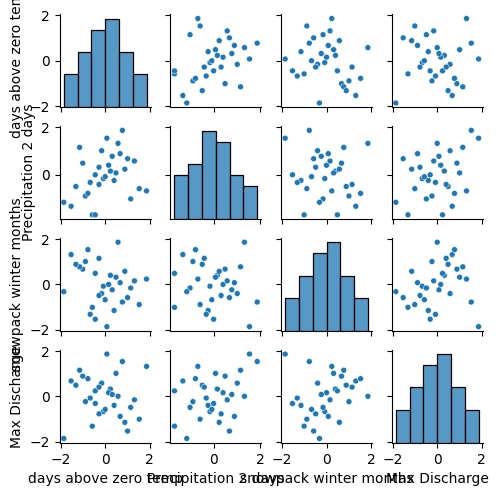

In [255]:
def sd_normal(data):
    sd_data = stats.norm.ppf(data)
    return sd_data

sd_data = pd.DataFrame(sd_normal(unity_data), columns = data.columns)
sns.pairplot(sd_data, height=1.25,plot_kws=dict(size=.1))
plt.show()

In [256]:
import warnings  
warnings.filterwarnings("ignore")

M = cvm_statistic(DATA = data, names = data.columns, fig_name='cvm')#your code here. Use Banshee!
print(M)

                     Var1                    Var2         r   Clayton  \
0    days above zero temp    Precipitation 2 days  0.334678  0.016869   
1    days above zero temp  snowpack winter months -0.235935  0.015196   
2    days above zero temp           Max Discharge -0.147812  0.022327   
3    Precipitation 2 days  snowpack winter months -0.135296  0.011884   
4    Precipitation 2 days           Max Discharge  0.254461  0.027368   
5  snowpack winter months           Max Discharge   0.32621  0.036984   

      Frank  Gaussian    Gumbel  
0   0.02282  0.036145  0.040909  
1  0.037674  0.031073  0.033777  
2  0.018546  0.017074  0.019933  
3  0.025649  0.021869   0.01231  
4  0.024953  0.022268  0.021765  
5  0.020466  0.045373   0.03205  


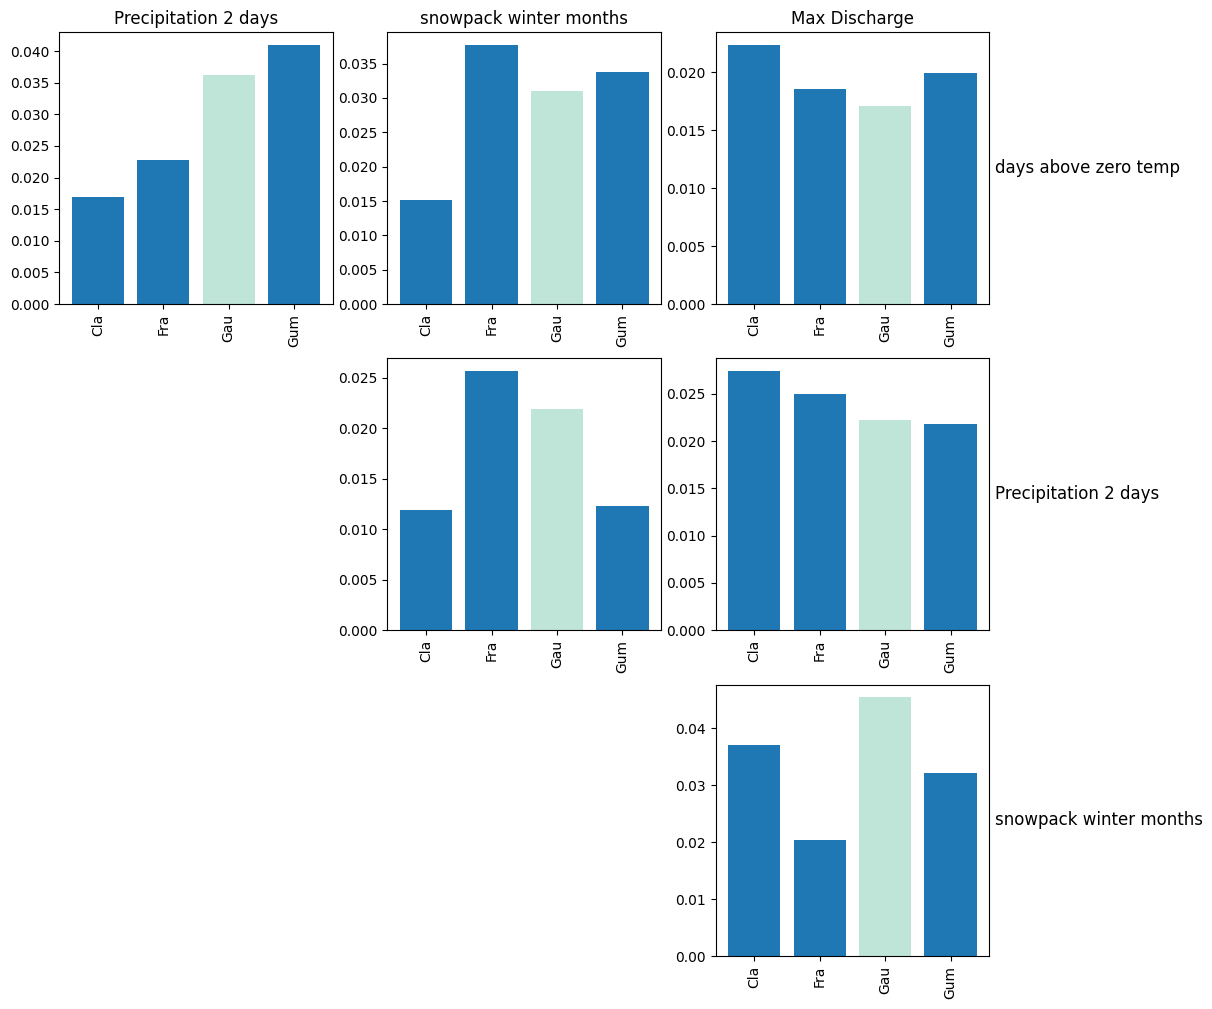

In [257]:
import warnings  
warnings.filterwarnings("ignore")

M = cvm_statistic(DATA = data, plot = 1, names = data.columns, fig_name='cvm')
plt.show()